<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/risk/neqsim_risk_framework_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim risk framework: process risk, availability, LOPA and SIS

This end-to-end notebook demonstrates how the NeqSim risk framework can be coupled directly to a physical process model. The workflow is: **process model → equipment failure consequence → degraded operation → reliability and Monte Carlo availability → LOPA/SIS protection layers → residual risk**.

The examples are intended for teaching, concept screening, RAM studies, brownfield analysis and agentic engineering workflows. Reliability values, initiating-event frequencies, IPL PFDs and SIL assumptions are illustrative unless replaced by project-approved data.

Risk framework documentation: https://equinor.github.io/neqsim/risk/index.html

In [1]:
%pip -q install neqsim

from neqsim import jneqsim
import json
import pandas as pd
import matplotlib.pyplot as plt

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
ProductionImpactAnalyzer = jneqsim.process.util.optimizer.ProductionImpactAnalyzer
DegradedOperationOptimizer = jneqsim.process.util.optimizer.DegradedOperationOptimizer
OperationalRiskSimulator = jneqsim.process.safety.risk.OperationalRiskSimulator
ReliabilityDataSource = jneqsim.process.equipment.failure.ReliabilityDataSource
RiskEvent = jneqsim.process.safety.risk.RiskEvent
SISIntegratedRiskModel = jneqsim.process.safety.risk.sis.SISIntegratedRiskModel
SafetyInstrumentedFunction = jneqsim.process.safety.risk.sis.SafetyInstrumentedFunction

print('NeqSim process and risk framework classes loaded')

Note: you may need to restart the kernel to use updated packages.


NeqSim process and risk framework classes loaded


## 1. Build the physical process model

The risk calculation starts from a normal NeqSim `ProcessSystem`, so equipment criticality and production consequences are tied to the same thermodynamic/process model used for engineering simulation.

In [2]:
fluid = SystemSrkEos(308.15, 55.0)
fluid.addComponent('methane', 0.86)
fluid.addComponent('ethane', 0.08)
fluid.addComponent('propane', 0.035)
fluid.addComponent('n-butane', 0.015)
fluid.addComponent('CO2', 0.01)
fluid.setMixingRule('classic')

process = ProcessSystem()
feed = Stream('Well Feed', fluid)
feed.setFlowRate(100000.0, 'kg/hr')
feed.setTemperature(35.0, 'C')
feed.setPressure(55.0, 'bara')
process.add(feed)
separator = Separator('Inlet Separator', feed)
process.add(separator)
compressor = Compressor('Export Compressor', separator.getGasOutStream())
compressor.setOutletPressure(120.0, 'bara')
process.add(compressor)
cooler = Cooler('Export Cooler', compressor.getOutletStream())
cooler.setOutTemperature(35.0, 'C')
process.add(cooler)
export = Stream('Export Gas', cooler.getOutletStream())
process.add(export)
process.run()
baseline = export.getFlowRate('kg/hr')
print(f'Baseline export: {baseline:,.0f} kg/h')
print(f'Compressor power: {compressor.getPower("kW"):,.0f} kW')
assert baseline > 0.0

Baseline export: 100,000 kg/h
Compressor power: 2,861 kW


## 2. Production impact and equipment criticality

`ProductionImpactAnalyzer` evaluates how loss of a named unit changes the selected product stream. The resulting production consequence is process-coupled rather than assigned manually.

Export compressor failure
  baseline production: 100,000 kg/h
  failed production:   100,000 kg/h
  production loss:     0.0%
  recommended action:  MANUAL_REVIEW


,equipment,production_loss_percent
0,"(I, n, l, e, t, , S, e, p, a, r, a, t, o, r)",0.0
1,"(E, x, p, o, r, t, , C, o, m, p, r, e, s, s, ...",0.0
2,"(E, x, p, o, r, t, , C, o, o, l, e, r)",0.0


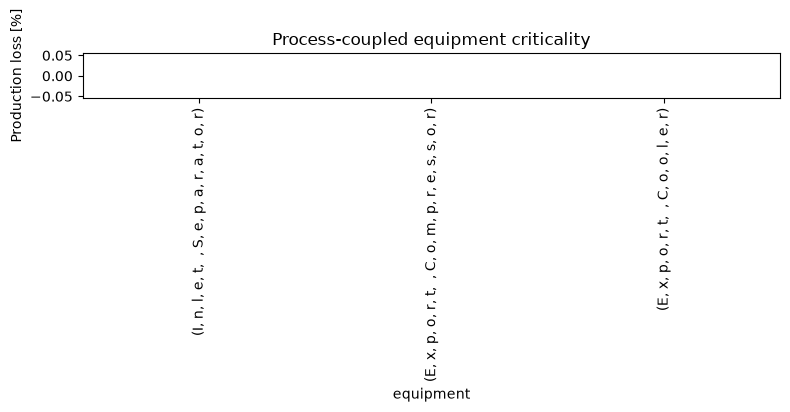

In [3]:
analyzer = ProductionImpactAnalyzer(process)
analyzer.setFeedStreamName('Well Feed')
analyzer.setProductStreamName('Export Gas')
impact = analyzer.analyzeFailureImpact('Export Compressor')
print('Export compressor failure')
print(f'  baseline production: {impact.getBaselineProductionRate():,.0f} kg/h')
print(f'  failed production:   {impact.getProductionWithFailure():,.0f} kg/h')
print(f'  production loss:     {impact.getPercentLoss():.1f}%')
print(f'  recommended action:  {impact.getRecommendedAction()}')

ranking = list(analyzer.rankEquipmentByCriticality())
criticality_df = pd.DataFrame([{'equipment': r.getEquipmentName(), 'production_loss_percent': r.getPercentLoss()} for r in ranking]).sort_values('production_loss_percent', ascending=False)
display(criticality_df)
criticality_df.plot.bar(x='equipment', y='production_loss_percent', legend=False, figsize=(8,4))
plt.ylabel('Production loss [%]')
plt.title('Process-coupled equipment criticality')
plt.tight_layout()
plt.show()

## 3. Degraded operation and recovery

A failure need not imply complete shutdown. NeqSim can search for a reduced-capacity operating state and return a recovery-plan object.

In [4]:
optimizer = DegradedOperationOptimizer(process)
optimizer.setFeedStreamName('Well Feed')
optimizer.setProductStreamName('Export Gas')
degraded = optimizer.optimizeWithEquipmentDown('Export Compressor')
print(f'Capacity factor: {100.0 * degraded.getCapacityFactor():.1f}%')
print(f'Optimal feed rate: {degraded.getOptimalFlowRate():,.0f} kg/h')
print(f'Optimal production: {degraded.getOptimalProduction():,.0f} kg/h')
print('\nRecovery plan:')
print(optimizer.createRecoveryPlan('Export Compressor').toString())

Capacity factor: 100.0%
Optimal feed rate: 100,000 kg/h
Optimal production: 100,000 kg/h

Recovery plan:
=== Recovery Plan for Export Compressor ===
Expected Production: 100000 kg/hr
Estimated Recovery Time: 6.0 hours

Actions:
  [IMMEDIATE] Reduce feed rate to 100000 kg/hr (0.0 hrs)
  [IMMEDIATE] Adjust Export Compressor outlet pressure (bara) to 55.00 (0.0 hrs)
  [IMMEDIATE] Adjust Export Gas flow (kg/hr) to 100000.00 (0.0 hrs)
  [IMMEDIATE] Adjust Well Feed flow (kg/hr) to 100000.00 (0.0 hrs)
  [STABILIZATION] Monitor process stability for 30 minutes (0.5 hrs)
  [REPAIR] Repair Export Compressor (estimated 4.0 hours) (4.0 hrs)
  [RESTORATION] Gradually increase feed rate to baseline (1.0 hrs)



## 4. Reliability data and Monte Carlo production availability

The `OperationalRiskSimulator` combines equipment reliability assumptions with process production consequences. Replace illustrative/default reliability data with governed project values for real studies.

In [5]:
reliability = ReliabilityDataSource.getInstance()
comp_rel = reliability.getReliabilityData('Compressor', 'Centrifugal')
print('Example reliability record for centrifugal compressor')
print(f'  MTBF: {comp_rel.getMtbf():,.0f} h')
print(f'  MTTR: {comp_rel.getMttr():,.0f} h')
print(f'  availability: {100.0 * comp_rel.getAvailability():.2f}%')

risk_sim = OperationalRiskSimulator(process)
risk_sim.setFeedStreamName('Well Feed')
risk_sim.setProductStreamName('Export Gas')
risk_sim.setRandomSeed(42)
risk_sim.addEquipmentMtbf('Export Compressor', 25000.0, 72.0)
risk_sim.addEquipmentMtbf('Export Cooler', 50000.0, 24.0)
risk_sim.addEquipmentMtbf('Inlet Separator', 250000.0, 48.0)
mc = risk_sim.runSimulation(1000, 365)
print('\nMonte Carlo result')
print(f'  mean availability: {mc.getMeanAvailability():.2f}%')
print(f'  production efficiency: {mc.getProductionEfficiency():.2f}%')
print(f'  mean failures/year: {mc.getMeanFailureCount():.2f}')
print(f'  mean downtime: {mc.getMeanDowntimeHours():.1f} h')
print(f'  production P10/P50/P90: {mc.getP10Production():,.0f} / {mc.getP50Production():,.0f} / {mc.getP90Production():,.0f}')
report = json.loads(str(mc.toJson()))
print('Available JSON result fields:', sorted(report.keys()))
assert 0.0 <= mc.getMeanAvailability() <= 100.0

Example reliability record for centrifugal compressor
  MTBF: 25,000 h
  MTTR: 72 h
  availability: 99.71%



Monte Carlo result
  mean availability: 99.67%
  production efficiency: 100.00%
  mean failures/year: 0.51
  mean downtime: 28.8 h
  production P10/P50/P90: 876,000,000 / 876,000,000 / 876,000,000
Available JSON result fields: ['availabilityStatistics', 'baselineProductionRate_kg_hr', 'equipmentAvailability', 'failureStatistics', 'iterations', 'maxPossibleProduction_kg', 'productionStatistics', 'timeHorizonDays']


## 5. LOPA: initiating event and independent protection layer

The same overall process can now be viewed from a safety-barrier perspective. We use an illustrative HP-vessel overpressure initiating event and credit a BPCS pressure-control IPL. In real LOPA work, event frequency, IPL independence and PFD must be justified by the hazard study.

In [6]:
event_name = 'HP vessel overpressure'
f_ie = 0.1
bpcs_pfd = 0.1
model = SISIntegratedRiskModel('HP vessel LOPA')
model.addInitiatingEvent(event_name, f_ie, RiskEvent.ConsequenceCategory.MAJOR)
bpcs = SISIntegratedRiskModel.IndependentProtectionLayer('BPCS pressure control', bpcs_pfd, SISIntegratedRiskModel.IndependentProtectionLayer.IPLType.BPCS)
bpcs.addApplicableEvent(event_name)
model.addIPL(bpcs)
print(f'Initiating event: {event_name}')
print(f'Initiating frequency: {f_ie:.3g} per year')
print(f'Credited BPCS PFD: {bpcs_pfd:.3g}')

Initiating event: HP vessel overpressure
Initiating frequency: 0.1 per year
Credited BPCS PFD: 0.1


## 6. Add a safety instrumented function and perform LOPA

The SIF builder provides a traceable ID, description, SIL label, PFD, initiating event, protected equipment and safe state. The independent Python arithmetic below acts as a transparent notebook validation gate.

In [7]:
sif_pfd = 0.005
esd = (SafetyInstrumentedFunction.builder()
       .id('SIF-001')
       .name('High-pressure ESD')
       .description('Isolate the HP vessel on confirmed high pressure')
       .sil(2)
       .pfd(sif_pfd)
       .initiatingEvent(event_name)
       .addProtectedEquipment('HP vessel')
       .safeState('Isolated')
       .build())
model.addSIF(esd)
result = model.performLOPA(event_name)
expected = f_ie * bpcs_pfd * sif_pfd
actual = result.getMitigatedFrequency()
print(f'SIF PFD: {sif_pfd:.3g}')
print(f'Expected mitigated frequency: {expected:.3e} per year')
print(f'NeqSim mitigated frequency:   {actual:.3e} per year')
print(f'Total risk-reduction factor:  {result.getTotalRRF():.1f}')
assert abs(actual - expected) < 1.0e-12
assert abs(result.getTotalRRF() - 1.0/(bpcs_pfd*sif_pfd)) < 1.0e-8

SIF PFD: 0.005
Expected mitigated frequency: 5.000e-05 per year
NeqSim mitigated frequency:   5.000e-05 per year
Total risk-reduction factor:  2000.0


## 7. Protection-layer sensitivity

This sweep illustrates the multiplicative nature of LOPA. It is a teaching sensitivity, not a basis for selecting or tuning a PFD without engineering evidence.

,SIF PFD,mitigated frequency [/yr],total RRF
0,0.100,0.00100,100.000000
1,0.030,0.00030,333.333333
2,0.010,0.00010,1000.000000
3,0.005,0.00005,2000.000000
4,0.003,0.00003,3333.333333
5,0.001,0.00001,10000.000000


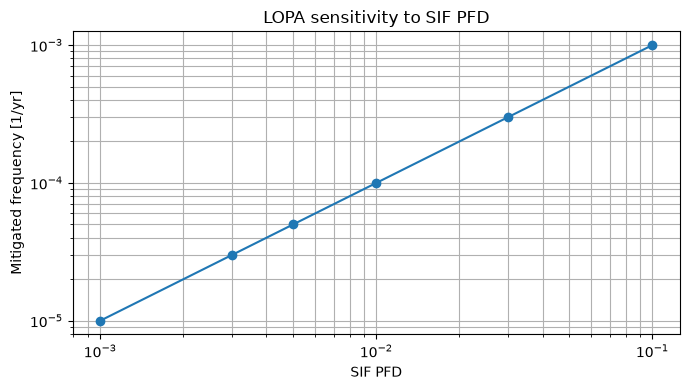

In [8]:
sif_pfds = [0.1, 0.03, 0.01, 0.005, 0.003, 0.001]
sens = pd.DataFrame([{'SIF PFD': pfd, 'mitigated frequency [/yr]': f_ie*bpcs_pfd*pfd, 'total RRF': 1.0/(bpcs_pfd*pfd)} for pfd in sif_pfds])
display(sens)
plt.figure(figsize=(7,4))
plt.loglog(sens['SIF PFD'], sens['mitigated frequency [/yr]'], marker='o')
plt.xlabel('SIF PFD')
plt.ylabel('Mitigated frequency [1/yr]')
plt.title('LOPA sensitivity to SIF PFD')
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

## 8. From notebook to agentic risk workflow

A useful NeqSim agentic pattern is: **detect changed condition → update process model → evaluate equipment consequence → run reliability/risk scenario → evaluate protection layers → propose degraded operating point → return auditable result objects**. The process model remains the physics authority while the agent coordinates scenarios and decisions.

Natural extensions include dynamic startup/shutdown risk, bow-tie analysis, condition-based reliability, real-time risk monitoring, multi-asset portfolio risk, and economic consequence integration.

This notebook demonstrates software capability. It does not replace a governed RAM study, HAZOP/LOPA, SIL verification or approved reliability database.